In [ ]:
!pip install cryptography pycryptodome psutil matplotlib tqdm pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 24.9 MB/s eta 0:00:00


In [ ]:
import os
import time
import psutil
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# Şifreleme kütüphaneleri
from cryptography.hazmat.primitives.ciphers import Cipher, algorithms as crypto_algo, modes
from cryptography.hazmat.backends import default_backend
from Crypto.PublicKey import RSA
from Crypto.Cipher import PKCS1_OAEP, Blowfish, DES3




In [ ]:
def generate_random_data(size_mb):
    """Belirtilen MB boyutunda rastgele veri üretir"""
    return os.urandom(size_mb * 1024 * 1024)

sizes = [1, 5, 10]
data_samples = {f"{s}MB": generate_random_data(s) for s in sizes}
print("✅ Rastgele veriler oluşturuldu:", list(data_samples.keys()))


✅ Rastgele veriler oluşturuldu: ['1MB', '5MB', '10MB']


In [ ]:
def measure_performance(func, data):
    """Bir algoritmanın şifreleme ve çözme süresini ve bellek farkını ölçer."""
    process = psutil.Process(os.getpid())

    mem_before = process.memory_info().rss
    start = time.perf_counter()
    func(data)
    end = time.perf_counter()
    mem_after = process.memory_info().rss

    return {
        "time_sec": round(end - start, 4),
        "mem_mb": round((mem_after - mem_before) / (1024 * 1024), 4)
    }


In [ ]:
# AES
def test_aes(data):
    key = os.urandom(32)
    iv = os.urandom(16)
    cipher = Cipher(crypto_algo.AES(key), modes.CBC(iv), backend=default_backend())
    encryptor = cipher.encryptor()
    # AES blok boyutu 16 bayt olduğu için veriyi 16'nın katına yuvarlıyoruz
    ciphertext = encryptor.update(data[:len(data)//16*16]) + encryptor.finalize()
    decryptor = cipher.decryptor()
    decryptor.update(ciphertext) + decryptor.finalize()

# RSA
def test_rsa(data):
    key = RSA.generate(2048)
    cipher = PKCS1_OAEP.new(key)
    chunk_size = 190  # RSA maksimum şifrelenebilir parça boyutu (2048-bit için)
    # Küçük bir veri parçası üzerinde test yapıyoruz (örnek: ilk 1KB)
    ciphertext = b''.join([cipher.encrypt(data[i:i+chunk_size]) for i in range(0, len(data[:1024]), chunk_size)])
    decipher = PKCS1_OAEP.new(key)
    b''.join([decipher.decrypt(ciphertext[i:i+256]) for i in range(0, len(ciphertext), 256)])

# Blowfish
def test_blowfish(data):
    key = os.urandom(16)
    cipher = Blowfish.new(key, Blowfish.MODE_CBC)
    bs = Blowfish.block_size
    plen = bs - len(data) % bs
    data += bytes([plen])*plen
    ciphertext = cipher.encrypt(data)
    decipher = Blowfish.new(key, Blowfish.MODE_CBC, cipher.iv)
    decipher.decrypt(ciphertext)

# ChaCha20
def test_chacha20(data):
    key = os.urandom(32)
    nonce = os.urandom(16)
    algorithm = crypto_algo.ChaCha20(key, nonce)
    cipher = Cipher(algorithm, mode=None, backend=default_backend())
    encryptor = cipher.encryptor()
    ciphertext = encryptor.update(data)
    decryptor = cipher.decryptor()
    decryptor.update(ciphertext)

#DES3

def test_3des(data):
    key = DES3.adjust_key_parity(os.urandom(24))
    cipher = DES3.new(key, DES3.MODE_ECB)
    plen = 8 - len(data) % 8
    data += bytes([plen])*plen
    ciphertext = cipher.encrypt(data)
    decipher = DES3.new(key, DES3.MODE_ECB)
    decipher.decrypt(ciphertext)


In [ ]:
crypto_algorithms = {
    "AES": test_aes,
    "RSA": test_rsa,
    "Blowfish": test_blowfish,
    "ChaCha20": test_chacha20,
     "3DES": test_3des
}
results = []

for name, func in crypto_algorithms.items():
    for size, data in data_samples.items():
        print(f"🔹 {name} - {size} test ediliyor...")
        res = measure_performance(func, data)
        res["algorithm"] = name
        res["size"] = size
        results.append(res)

print("\n✅ Tüm testler tamamlandı.")

🔹 AES - 1MB test ediliyor...
🔹 AES - 5MB test ediliyor...
🔹 AES - 10MB test ediliyor...
🔹 RSA - 1MB test ediliyor...
🔹 RSA - 5MB test ediliyor...
🔹 RSA - 10MB test ediliyor...
🔹 Blowfish - 1MB test ediliyor...
🔹 Blowfish - 5MB test ediliyor...
🔹 Blowfish - 10MB test ediliyor...
🔹 ChaCha20 - 1MB test ediliyor...
🔹 ChaCha20 - 5MB test ediliyor...
🔹 ChaCha20 - 10MB test ediliyor...
🔹 3DES - 1MB test ediliyor...
🔹 3DES - 5MB test ediliyor...
🔹 3DES - 10MB test ediliyor...

✅ Tüm testler tamamlandı.


In [ ]:
df = pd.DataFrame(results)
df = df[["algorithm", "size", "time_sec", "mem_mb"]]


In [ ]:
print("📊 Şifreleme Algoritmalarının Performans Sonuçları:")
print(df.to_string(index=False))


📊 Şifreleme Algoritmalarının Performans Sonuçları:
algorithm size  time_sec   mem_mb
      AES  1MB    0.0178   0.8828
      AES  5MB    0.0205  -0.0078
      AES 10MB    0.0450   0.0000
      RSA  1MB    0.3126   0.3672
      RSA  5MB    0.2372   0.0000
      RSA 10MB    0.2746   0.0000
 Blowfish  1MB    0.0212   0.0273
 Blowfish  5MB    0.0956   0.0000
 Blowfish 10MB    0.1988   0.0039
 ChaCha20  1MB    0.0015   0.0039
 ChaCha20  5MB    0.0111  14.8750
 ChaCha20 10MB    0.0185 -14.8750
     3DES  1MB    0.0819   0.0547
     3DES  5MB    0.3889   0.0039
     3DES 10MB    0.8084   0.0000


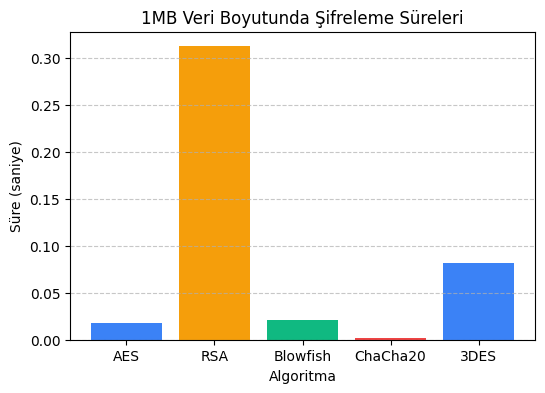

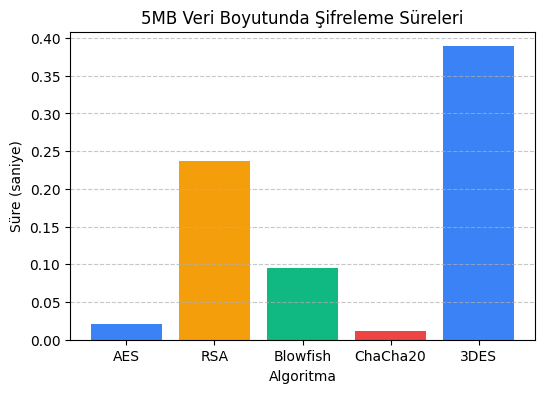

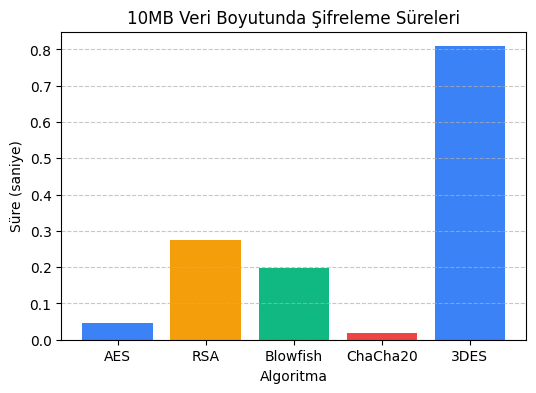

In [ ]:
for size in df["size"].unique():
    subset = df[df["size"] == size]
    plt.figure(figsize=(6,4))
    plt.bar(subset["algorithm"], subset["time_sec"], color=['#3b82f6','#f59e0b','#10b981','#ef4444'])
    plt.title(f"{size} Veri Boyutunda Şifreleme Süreleri")
    plt.xlabel("Algoritma")
    plt.ylabel("Süre (saniye)")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


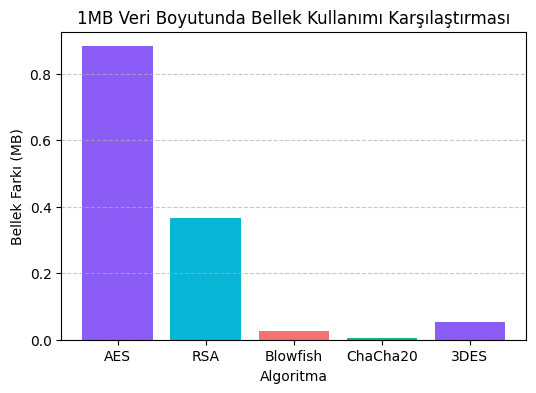

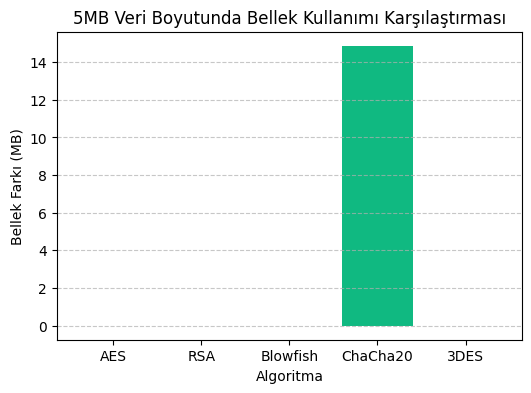

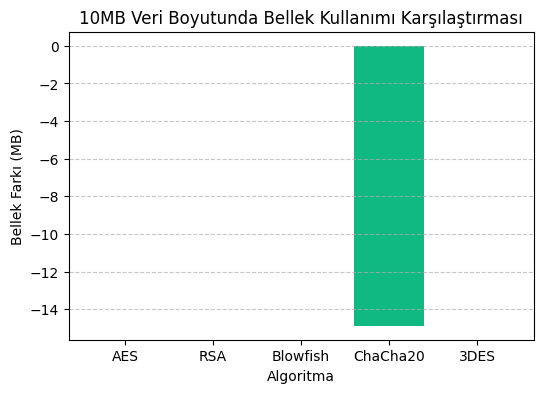

In [ ]:
for size in df["size"].unique():
    subset = df[df["size"] == size]
    plt.figure(figsize=(6,4))
    plt.bar(subset["algorithm"], subset["mem_mb"], color=['#8b5cf6','#06b6d4','#f87171','#10b981'])
    plt.title(f"{size} Veri Boyutunda Bellek Kullanımı Karşılaştırması")
    plt.xlabel("Algoritma")
    plt.ylabel("Bellek Farkı (MB)")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


In [ ]:
df.to_csv("sifreleme_sonuclari.csv", index=False)
print("💾 Sonuçlar 'sifreleme_sonuclari.csv' dosyasına kaydedildi.")


💾 Sonuçlar 'sifreleme_sonuclari.csv' dosyasına kaydedildi.
